# Chapter 4 Question 13 - Parts (e)-(j)

## Data Preparation

First, let's load the data and prepare training/test sets as in part (d).

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ISLP import load_data
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Load the Weekly data
Weekly = load_data('Weekly')

# Split data into training (1990-2008) and test (2009-2010)
train = Weekly[Weekly['Year'] <= 2008]
test = Weekly[Weekly['Year'] >= 2009]

# Prepare data with Lag2 only (as in part d)
X_train = train[['Lag2']].values
y_train = train['Direction'].values
X_test = test[['Lag2']].values
y_test = test['Direction'].values

print(f"Training set size: {len(train)} observations (1990-2008)")
print(f"Test set size: {len(test)} observations (2009-2010)")
print(f"\nTraining set distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest set distribution:")
print(pd.Series(y_test).value_counts())

Training set size: 985 observations (1990-2008)
Test set size: 104 observations (2009-2010)

Training set distribution:
Up      544
Down    441
Name: count, dtype: int64

Test set distribution:
Up      61
Down    43
Name: count, dtype: int64


##  (e) Repeat (d) using LDA.

LDA assumes that observations from each class are drawn from a Gaussian distribution with class-specific mean and common covariance matrix.

In [22]:
# Fit LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)

# Confusion matrix and accuracy
cm_lda = confusion_matrix(y_test, y_pred_lda, labels=['Down', 'Up'])
accuracy_lda = accuracy_score(y_test, y_pred_lda)

print("(e) LDA Results:")
print(f"Accuracy: {accuracy_lda:.4f} ({accuracy_lda*100:.2f}%)")
print(f"Confusion Matrix: [[{cm_lda[0,0]}, {cm_lda[0,1]}], [{cm_lda[1,0]}, {cm_lda[1,1]}]]")

(e) LDA Results:
Accuracy: 0.6250 (62.50%)
Confusion Matrix: [[9, 34], [5, 56]]


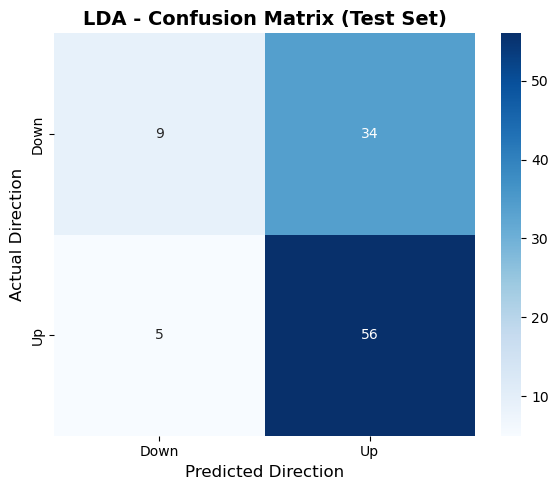

In [23]:
# Visualize LDA confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel('Predicted Direction', fontsize=12)
plt.ylabel('Actual Direction', fontsize=12)
plt.title('LDA - Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## (f) Repeat (d) using QDA.

QDA assumes that each class has its own covariance matrix, allowing for more flexible (quadratic) decision boundaries.

In [24]:
# Fit QDA model
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
y_pred_qda = qda.predict(X_test)

# Confusion matrix and accuracy
cm_qda = confusion_matrix(y_test, y_pred_qda, labels=['Down', 'Up'])
accuracy_qda = accuracy_score(y_test, y_pred_qda)

print("(f) QDA Results:")
print(f"Accuracy: {accuracy_qda:.4f} ({accuracy_qda*100:.2f}%)")
print(f"Confusion Matrix: [[{cm_qda[0,0]}, {cm_qda[0,1]}], [{cm_qda[1,0]}, {cm_qda[1,1]}]]")

(f) QDA Results:
Accuracy: 0.5865 (58.65%)
Confusion Matrix: [[0, 43], [0, 61]]


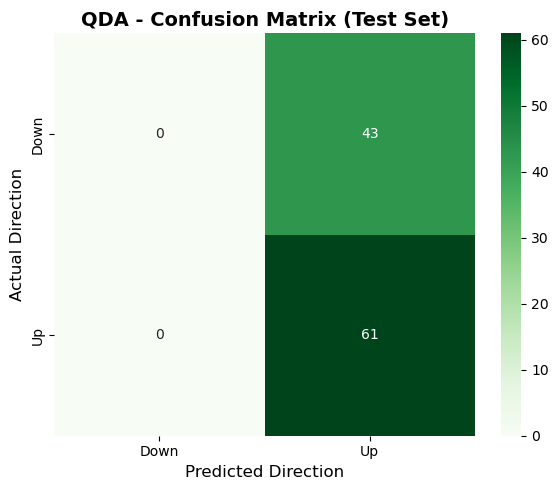

In [25]:
# Visualize QDA confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_qda, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel('Predicted Direction', fontsize=12)
plt.ylabel('Actual Direction', fontsize=12)
plt.title('QDA - Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## (g) Repeat (d) using KNN with K = 1.

KNN classifies based on the majority class of the K nearest neighbors. With K=1, it uses only the single nearest neighbor.

In [26]:
# Fit KNN model with K=1
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)
y_pred_knn1 = knn1.predict(X_test)

# Confusion matrix and accuracy
cm_knn1 = confusion_matrix(y_test, y_pred_knn1, labels=['Down', 'Up'])
accuracy_knn1 = accuracy_score(y_test, y_pred_knn1)

print("(g) KNN (K=1) Results:")
print(f"Accuracy: {accuracy_knn1:.4f} ({accuracy_knn1*100:.2f}%)")
print(f"Confusion Matrix: [[{cm_knn1[0,0]}, {cm_knn1[0,1]}], [{cm_knn1[1,0]}, {cm_knn1[1,1]}]]")

(g) KNN (K=1) Results:
Accuracy: 0.5000 (50.00%)
Confusion Matrix: [[22, 21], [31, 30]]


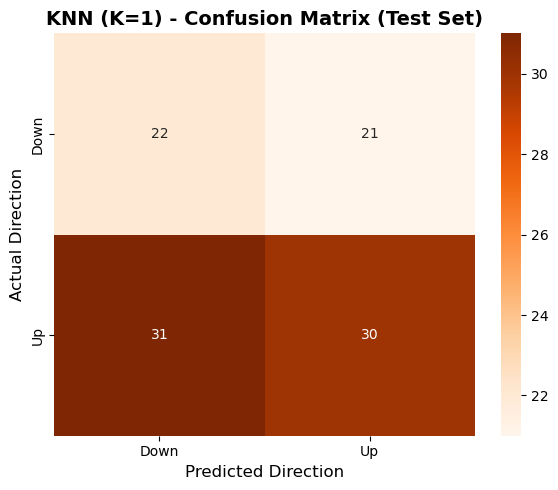

In [27]:
# Visualize KNN confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn1, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel('Predicted Direction', fontsize=12)
plt.ylabel('Actual Direction', fontsize=12)
plt.title('KNN (K=1) - Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## (h) Repeat (d) using naive Bayes.

Naive Bayes assumes features are independent given the class label, using Bayes' theorem for classification.

In [28]:
# Fit Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# Confusion matrix and accuracy
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=['Down', 'Up'])
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("(h) Naive Bayes Results:")
print(f"Accuracy: {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)")
print(f"Confusion Matrix: [[{cm_nb[0,0]}, {cm_nb[0,1]}], [{cm_nb[1,0]}, {cm_nb[1,1]}]]")

(h) Naive Bayes Results:
Accuracy: 0.5865 (58.65%)
Confusion Matrix: [[0, 43], [0, 61]]


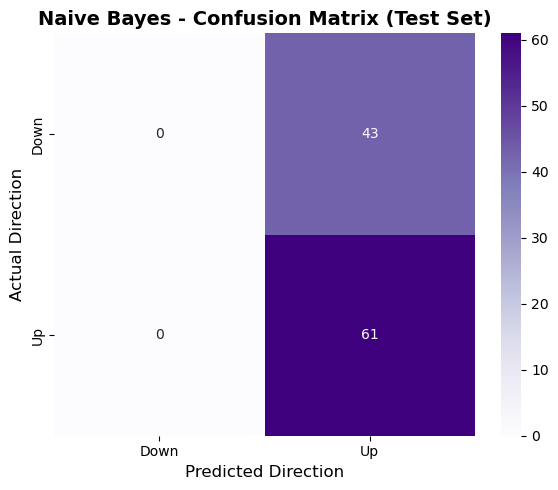

In [29]:
# Visualize Naive Bayes confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel('Predicted Direction', fontsize=12)
plt.ylabel('Actual Direction', fontsize=12)
plt.title('Naive Bayes - Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  (i) Which of these methods appears to provide the best results on this data?

Now let's compare all methods (including Logistic Regression from part d) to see which performs best.

In [30]:
# Add Logistic Regression for comparison
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)

# Create comparison table
results = pd.DataFrame({
    'Method': ['Logistic Regression', 'LDA', 'QDA', 'KNN (K=1)', 'Naive Bayes'],
    'Accuracy': [accuracy_logreg, accuracy_lda, accuracy_qda, accuracy_knn1, accuracy_nb]
})
results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results['Rank'] = range(1, len(results) + 1)
results = results[['Rank', 'Method', 'Accuracy']]

print("(i) COMPARISON OF ALL METHODS:")
print(results.to_string(index=False))
print(f"\nBest: {results.iloc[0]['Method']} - {results.iloc[0]['Accuracy']*100:.2f}%")

(i) COMPARISON OF ALL METHODS:
 Rank              Method  Accuracy
    1 Logistic Regression  0.625000
    2                 LDA  0.625000
    3                 QDA  0.586538
    4         Naive Bayes  0.586538
    5           KNN (K=1)  0.500000

Best: Logistic Regression - 62.50%


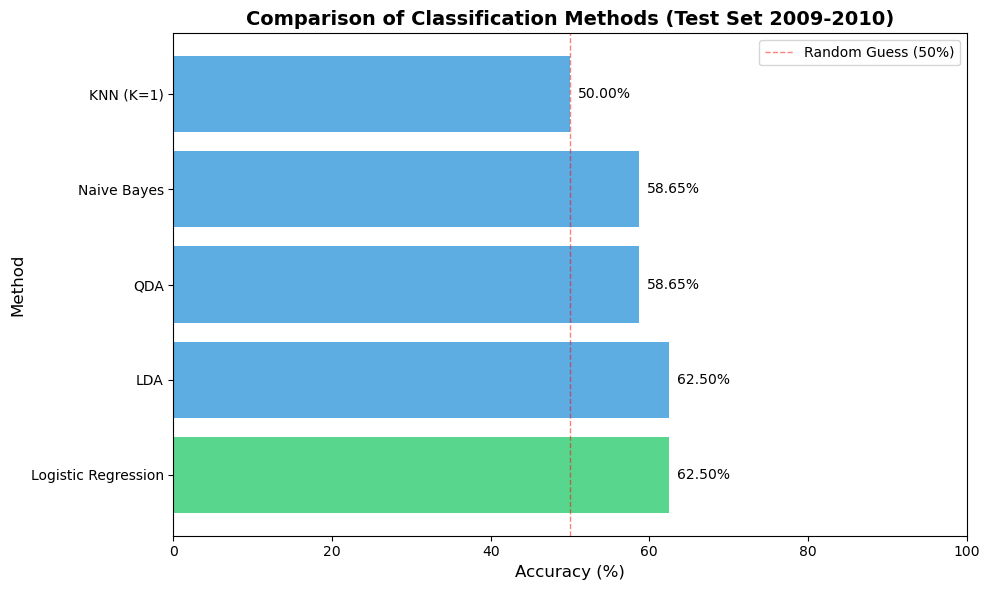

In [31]:
# Visualize comparison
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results))]
bars = plt.barh(results['Method'], results['Accuracy']*100, color=colors, alpha=0.8)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.ylabel('Method', fontsize=12)
plt.title('Comparison of Classification Methods (Test Set 2009-2010)', 
          fontsize=14, fontweight='bold')
plt.xlim(0, 100)

# Add percentage labels on bars
for i, (method, acc) in enumerate(zip(results['Method'], results['Accuracy'])):
    plt.text(acc*100 + 1, i, f'{acc*100:.2f}%', va='center', fontsize=10)

# Add reference line at 50% (random guess)
plt.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Random Guess (50%)')
plt.legend()
plt.tight_layout()
plt.show()

## (j) Experimenting with Different Predictors and Combinations

Now let's experiment with:
1. Different combinations of predictors (Lag1-Lag5, Volume)
2. Interactions between predictors
3. Polynomial transformations
4. Different K values for KNN

### 1. Testing Different Predictor Combinations

In [32]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from itertools import combinations

# Define different predictor combinations to test
predictor_sets = [
    (['Lag1'], 'Lag1 only'),
    (['Lag2'], 'Lag2 only'),
    (['Lag3'], 'Lag3 only'),
    (['Lag1', 'Lag2'], 'Lag1 + Lag2'),
    (['Lag1', 'Lag2', 'Lag3'], 'Lag1 + Lag2 + Lag3'),
    (['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5'], 'All Lags'),
    (['Lag2', 'Volume'], 'Lag2 + Volume'),
    (['Lag1', 'Lag2', 'Volume'], 'Lag1 + Lag2 + Volume'),
    (['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume'], 'All Predictors'),
]

# Test all combinations with all methods
results_exp = []

for predictors, name in predictor_sets:
    X_train_exp = train[predictors].values
    X_test_exp = test[predictors].values
    
    # Test each method
    methods = [
        ('Logistic Regression', LogisticRegression(random_state=42, max_iter=1000)),
        ('LDA', LinearDiscriminantAnalysis()),
        ('QDA', QuadraticDiscriminantAnalysis()),
        ('KNN (K=1)', KNeighborsClassifier(n_neighbors=1)),
        ('Naive Bayes', GaussianNB())
    ]
    
    for method_name, model in methods:
        try:
            model.fit(X_train_exp, y_train)
            y_pred = model.predict(X_test_exp)
            acc = accuracy_score(y_test, y_pred)
            results_exp.append({
                'Predictors': name,
                'Method': method_name,
                'Accuracy': acc
            })
        except Exception as e:
            # Some models might fail with certain predictor combinations
            results_exp.append({
                'Predictors': name,
                'Method': method_name,
                'Accuracy': 0.0
            })

# Create DataFrame and display results
df_results = pd.DataFrame(results_exp)
pivot_table = df_results.pivot(index='Predictors', columns='Method', values='Accuracy')

print("(j.1) Different Predictor Combinations:")
print(pivot_table.round(4))

(j.1) Different Predictor Combinations:
Method                KNN (K=1)     LDA  Logistic Regression  Naive Bayes  \
Predictors                                                                  
All Lags                 0.5192  0.5481               0.5481       0.4808   
All Predictors           0.4808  0.4615               0.4615       0.4519   
Lag1 + Lag2              0.4808  0.5769               0.5769       0.5385   
Lag1 + Lag2 + Lag3       0.4904  0.5769               0.5769       0.5385   
Lag1 + Lag2 + Volume     0.5000  0.5288               0.5288       0.4231   
Lag1 only                0.4615  0.5673               0.5673       0.5865   
Lag2 + Volume            0.5577  0.5385               0.5385       0.4615   
Lag2 only                0.5000  0.6250               0.6250       0.5865   
Lag3 only                0.5288  0.5865               0.5865       0.5865   

Method                   QDA  
Predictors                    
All Lags              0.4615  
All Predictors     

In [33]:
# Find best overall combination
best_result = df_results.loc[df_results['Accuracy'].idxmax()]
print(f"\nBest Overall Combination:")
print(f"  Predictors: {best_result['Predictors']}")
print(f"  Method: {best_result['Method']}")
print(f"  Accuracy: {best_result['Accuracy']:.4f} ({best_result['Accuracy']*100:.2f}%)")


Best Overall Combination:
  Predictors: Lag2 only
  Method: Logistic Regression
  Accuracy: 0.6250 (62.50%)


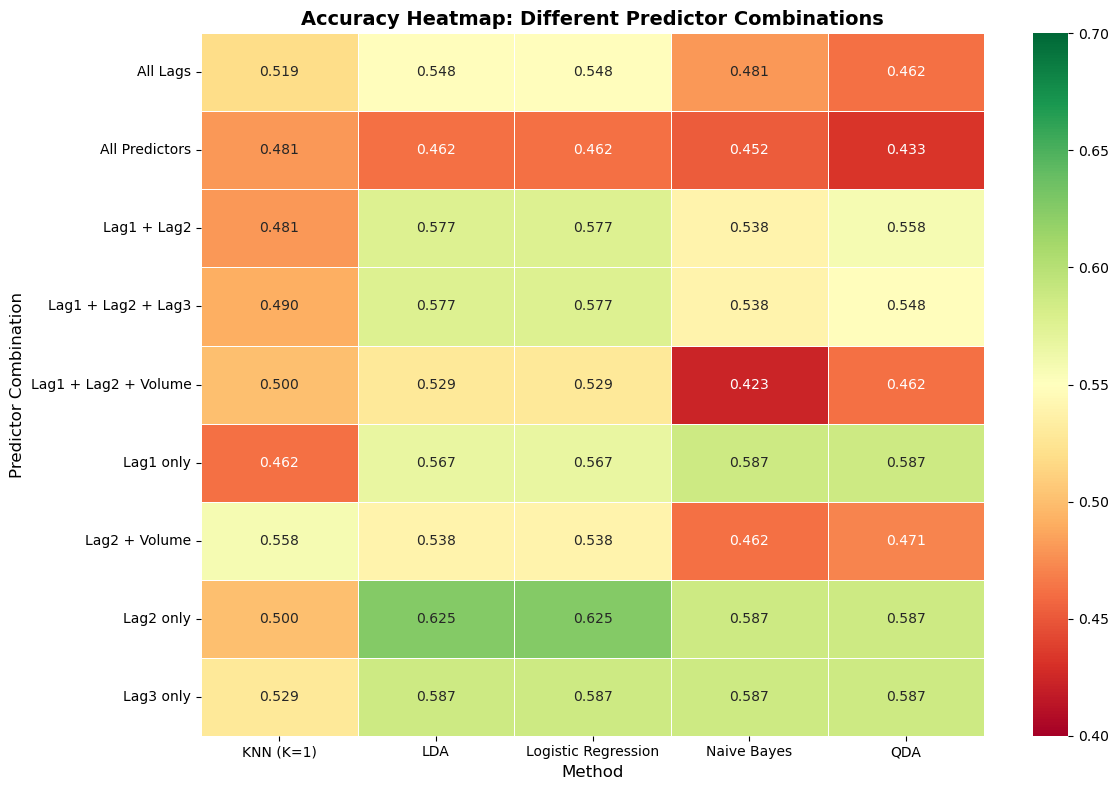

In [34]:
# Visualize heatmap of accuracies
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.4, vmax=0.7, center=0.55, linewidths=0.5)
plt.title('Accuracy Heatmap: Different Predictor Combinations', 
          fontsize=14, fontweight='bold')
plt.xlabel('Method', fontsize=12)
plt.ylabel('Predictor Combination', fontsize=12)
plt.tight_layout()
plt.show()

### 2. Testing Different K Values for KNN

In [41]:
# Test KNN with different K values and predictor combinations
k_values = [1, 3, 5, 7, 10, 15, 20, 25, 30, 50, 100]
knn_results = []

# Test with different predictor sets
test_predictor_sets = [
    (['Lag2'], 'Lag2 only'),
    (['Lag1', 'Lag2'], 'Lag1 + Lag2'),
    (['Lag1', 'Lag2', 'Lag3'], 'Lag1-3'),
    (['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5'], 'All Lags'),
    (['Lag2', 'Volume'], 'Lag2 + Volume'),
]

for predictors, pred_name in test_predictor_sets:
    X_train_knn = train[predictors].values
    X_test_knn = test[predictors].values
    
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_knn, y_train)
        y_pred = knn.predict(X_test_knn)
        acc = accuracy_score(y_test, y_pred)
        knn_results.append({
            'K': k,
            'Predictors': pred_name,
            'Accuracy': acc
        })

# Create DataFrame
df_knn = pd.DataFrame(knn_results)
pivot_knn = df_knn.pivot(index='K', columns='Predictors', values='Accuracy')

# Find best K and predictor combination
best_knn = df_knn.loc[df_knn['Accuracy'].idxmax()]
print(f"(j.2) Best KNN: K={best_knn['K']}, {best_knn['Predictors']}, Accuracy={best_knn['Accuracy']:.4f}")

(j.2) Best KNN: K=25, Lag1 + Lag2, Accuracy=0.6250


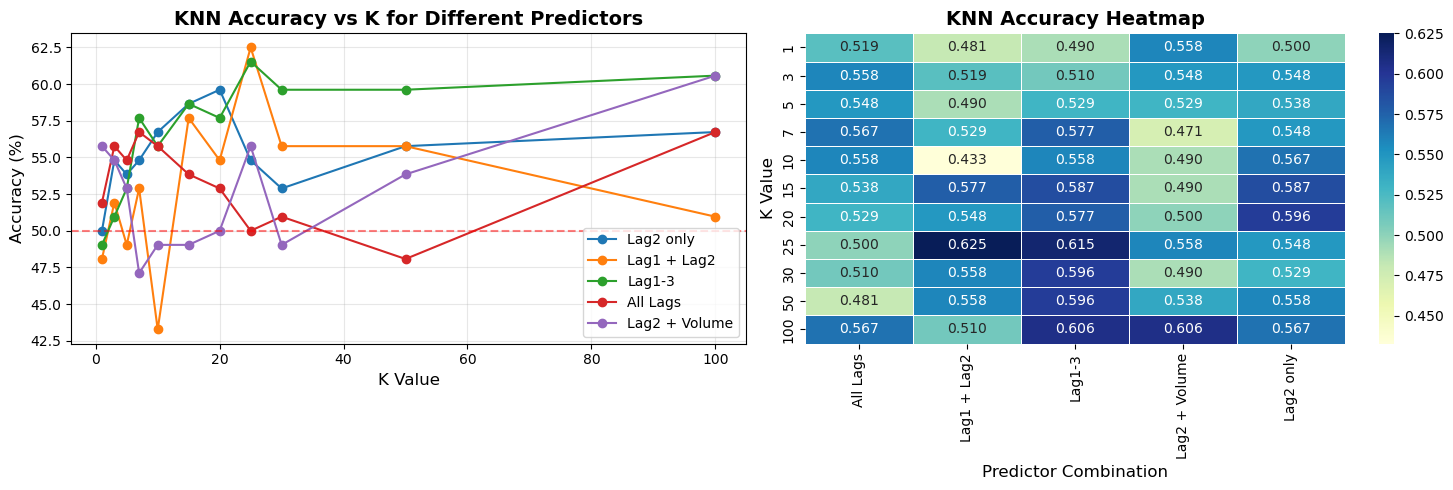

In [36]:
# Visualize KNN performance vs K
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Line plot for different predictor combinations
for pred_name in test_predictor_sets:
    subset = df_knn[df_knn['Predictors'] == pred_name[1]]
    axes[0].plot(subset['K'], subset['Accuracy']*100, marker='o', label=pred_name[1])

axes[0].set_xlabel('K Value', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('KNN Accuracy vs K for Different Predictors', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Random')

# Plot 2: Heatmap
pivot_knn_plot = df_knn.pivot(index='K', columns='Predictors', values='Accuracy')
sns.heatmap(pivot_knn_plot, annot=True, fmt='.3f', cmap='YlGnBu', 
            ax=axes[1], linewidths=0.5)
axes[1].set_title('KNN Accuracy Heatmap', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predictor Combination', fontsize=12)
axes[1].set_ylabel('K Value', fontsize=12)

plt.tight_layout()
plt.show()

### 3. Testing with Polynomial Features and Interactions

In [37]:
# Test with polynomial features (interactions and squared terms)
poly_results = []

# Base predictors to transform
base_predictors = [
    (['Lag1', 'Lag2'], 'Lag1 + Lag2'),
    (['Lag1', 'Lag2', 'Lag3'], 'Lag1 + Lag2 + Lag3'),
    (['Lag2', 'Volume'], 'Lag2 + Volume'),
]

for predictors, pred_name in base_predictors:
    X_train_base = train[predictors].values
    X_test_base = test[predictors].values
    
    # Create polynomial features (degree 2: includes interactions and squares)
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_base)
    X_test_poly = poly.transform(X_test_base)
    
    # Test with different methods
    methods = [
        ('Logistic Regression', LogisticRegression(random_state=42, max_iter=1000)),
        ('LDA', LinearDiscriminantAnalysis()),
        ('QDA', QuadraticDiscriminantAnalysis()),
        ('Naive Bayes', GaussianNB())
    ]
    
    for method_name, model in methods:
        try:
            model.fit(X_train_poly, y_train)
            y_pred = model.predict(X_test_poly)
            acc = accuracy_score(y_test, y_pred)
            poly_results.append({
                'Base Predictors': pred_name,
                'Method': method_name,
                'Accuracy': acc,
                'Features': 'Polynomial (degree 2)'
            })
        except:
            pass

# Create DataFrame
df_poly = pd.DataFrame(poly_results)
pivot_poly = df_poly.pivot(index='Base Predictors', columns='Method', values='Accuracy')

print("(j.3) Polynomial Features (Degree 2):")
print(pivot_poly.round(4))

if len(df_poly) > 0:
    best_poly = df_poly.loc[df_poly['Accuracy'].idxmax()]
    print(f"Best: {best_poly['Method']}, {best_poly['Base Predictors']}, Accuracy={best_poly['Accuracy']:.4f}")

(j.3) Polynomial Features (Degree 2):
Method                 LDA  Logistic Regression  Naive Bayes     QDA
Base Predictors                                                     
Lag1 + Lag2         0.5577               0.5577       0.4519  0.4712
Lag1 + Lag2 + Lag3  0.5577               0.5481       0.4135  0.5096
Lag2 + Volume       0.5288               0.5288       0.4519  0.4904
Best: Logistic Regression, Lag1 + Lag2, Accuracy=0.5577


### 4. Final Best Model - Detailed Analysis

In [38]:
# Combine all results to find the absolute best model
all_results = []

# Add basic predictor combinations
all_results.extend(results_exp)

# Add KNN results
for _, row in df_knn.iterrows():
    all_results.append({
        'Predictors': f"{row['Predictors']} (KNN K={row['K']})",
        'Method': f"KNN (K={row['K']})",
        'Accuracy': row['Accuracy']
    })

# Add polynomial results
if len(df_poly) > 0:
    for _, row in df_poly.iterrows():
        all_results.append({
            'Predictors': f"{row['Base Predictors']} + Poly(2)",
            'Method': row['Method'],
            'Accuracy': row['Accuracy']
        })

# Create final comparison
df_all = pd.DataFrame(all_results)
df_all_sorted = df_all.sort_values('Accuracy', ascending=False).head(5)

print("(j.4) TOP 5 BEST CONFIGURATIONS:")
for i, (idx, row) in enumerate(df_all_sorted.iterrows(), 1):
    print(f"{i}. {row['Method']:20s} | {row['Predictors']:30s} | {row['Accuracy']:.4f}")

# Get the absolute best
best_overall = df_all_sorted.iloc[0]
print(f"\n*** BEST OVERALL: {best_overall['Method']} with {best_overall['Predictors']}")
print(f"*** Accuracy: {best_overall['Accuracy']:.4f} ({best_overall['Accuracy']*100:.2f}%)")

(j.4) TOP 5 BEST CONFIGURATIONS:
1. LDA                  | Lag2 only                      | 0.6250
2. Logistic Regression  | Lag2 only                      | 0.6250
3. KNN (K=25)           | Lag1 + Lag2 (KNN K=25)         | 0.6250
4. KNN (K=25)           | Lag1-3 (KNN K=25)              | 0.6154
5. KNN (K=100)          | Lag2 + Volume (KNN K=100)      | 0.6058

*** BEST OVERALL: LDA with Lag2 only
*** Accuracy: 0.6250 (62.50%)
